# Exercício 6 — Simulador de eventos com múltiplas filas e índice em árvore

Aluno: Henrique Goldstein Maluhy Mendes Amaral · DR1_AT · Infnet

Para rodar: Ambiente de execução → Executar tudo.

Regras dos eventos: letra minúscula é chegada na fila (`b` = chega um cliente na fila B), maiúscula é saída (`B` = a fila B atende o primeiro) e qualquer caractere que não seja letra tira um snapshot de todas as filas.

In [1]:
import random

import matplotlib.pyplot as plt
import pandas as pd

random.seed(42)

## 1. A fila: circular e com capacidade fixa

É a mesma fila do exercício 5.

In [2]:
class QueueOverflowError(Exception):
    """enqueue em fila cheia."""

class QueueUnderflowError(Exception):
    """dequeue em fila vazia."""


class Queue:
    def __init__(self, capacidade):
        self.capacidade = capacidade
        self.itens = [None] * capacidade
        self.inicio = 0
        self.fim = 0
        self.total = 0

    def enqueue(self, item):
        if self.total == self.capacidade:
            raise QueueOverflowError(f"fila cheia (capacidade {self.capacidade})")
        self.itens[self.fim] = item
        self.fim = (self.fim + 1) % self.capacidade
        self.total += 1

    def dequeue(self):
        if self.total == 0:
            raise QueueUnderflowError("fila vazia")
        item = self.itens[self.inicio]
        self.itens[self.inicio] = None
        self.inicio = (self.inicio + 1) % self.capacidade
        self.total -= 1
        return item

    def em_ordem(self):
        return [self.itens[(self.inicio + i) % self.capacidade] for i in range(self.total)]

## 2. O índice: uma BST dos clientes atendidos

A chave é o identificador completo do cliente, guardado como `(fila, número)` em vez de texto:

In [3]:
como_texto = sorted(["B2", "B17", "B1", "A10", "A9"])
como_chave = sorted([("B", 2), ("B", 17), ("B", 1), ("A", 10), ("A", 9)])
print("comparando a string:      ", como_texto)
print("comparando (fila, número):", [f"{fila}{numero}" for fila, numero in como_chave])

comparando a string:       ['A10', 'A9', 'B1', 'B17', 'B2']
comparando (fila, número): ['A9', 'A10', 'B1', 'B2', 'B17']


Comparando como texto, "B17" vem antes de "B2", e a listagem sairia errada. Com `(fila, número)` o número é comparado como número. A busca continua aceitando o texto "B17": converto na entrada.

In [4]:
class NoIndice:
    def __init__(self, chave, dados):
        self.chave = chave
        self.dados = dados
        self.esquerda = None
        self.direita = None


def para_chave(identificador):
    """'B17' → ('B', 17). Levanta ValueError se o texto não for um identificador válido."""
    if (not isinstance(identificador, str) or len(identificador) < 2
            or not identificador[0].isalpha() or not identificador[1:].isdigit()):
        raise ValueError(f"identificador inválido: {identificador!r} (o formato é letra + número, ex.: 'B17')")
    return identificador[0].upper(), int(identificador[1:])


class BinarySearchTree:
    def __init__(self):
        self.raiz = None
        self.tamanho = 0

    def insert(self, chave, dados):
        """Inserção iterativa. Devolve quantas comparações fez."""
        novo = NoIndice(chave, dados)
        self.tamanho += 1
        if self.raiz is None:
            self.raiz = novo
            return 0
        atual, comparacoes = self.raiz, 0
        while True:
            comparacoes += 1
            if chave < atual.chave:
                if atual.esquerda is None:
                    atual.esquerda = novo
                    return comparacoes
                atual = atual.esquerda
            else:
                if atual.direita is None:
                    atual.direita = novo
                    return comparacoes
                atual = atual.direita

    def search(self, identificador):
        """Devolve (dados ou None, comparações)."""
        chave = para_chave(identificador)
        atual, comparacoes = self.raiz, 0
        while atual is not None:
            comparacoes += 1
            if chave == atual.chave:
                return atual.dados, comparacoes
            atual = atual.esquerda if chave < atual.chave else atual.direita
        return None, comparacoes

    def in_order(self):
        resultado, pilha, atual = [], [], self.raiz
        while pilha or atual is not None:
            while atual is not None:
                pilha.append(atual)
                atual = atual.esquerda
            atual = pilha.pop()
            resultado.append(atual.dados)
            atual = atual.direita
        return resultado

    def altura(self):
        nivel, h = ([self.raiz] if self.raiz else []), 0
        while nivel:
            h += 1
            nivel = [f for no in nivel for f in (no.esquerda, no.direita) if f]
        return h

## 3. O simulador

- O número do cliente é dado na chegada, por fila. Se a fila estiver cheia, o cliente é recusado, mas o número dele aparece no log.
- O timestamp lógico é a posição do evento na string (o primeiro evento é o tick 1).
- Overflow, underflow e fila inexistente viram uma linha de ERRO no log, com o contexto, e a simulação continua.

In [5]:
class Simulador:
    FILAS = "ABCD"

    def __init__(self, capacidade=5):
        self.capacidade = capacidade
        self.filas = {nome: Queue(capacidade) for nome in self.FILAS}
        self.proximo_numero = {nome: 1 for nome in self.FILAS}
        self.indice = BinarySearchTree()
        self.log = []
        self.snapshots = []
        self.atendidos = 0

    def _registrar(self, tick, evento, tipo, mensagem):
        self.log.append({"tick": tick, "evento": evento, "tipo": tipo, "mensagem": mensagem})

    def processar(self, eventos):
        for tick, evento in enumerate(eventos, start=1):
            if not evento.isalpha():
                self._snapshot(tick, evento)
            elif evento.upper() not in self.filas:
                self._registrar(tick, evento, "ERRO", f"não existe fila '{evento.upper()}'")
            elif evento.islower():
                self._chegada(tick, evento, evento.upper())
            else:
                self._saida(tick, evento, evento)
        return self

    def _chegada(self, tick, evento, fila):
        numero = self.proximo_numero[fila]
        self.proximo_numero[fila] += 1
        identificador = f"{fila}{numero}"
        try:
            self.filas[fila].enqueue((identificador, tick))
            self._registrar(tick, evento, "chegada", f"{identificador} entrou na fila {fila}")
        except QueueOverflowError:
            espera = [c for c, _ in self.filas[fila].em_ordem()]
            self._registrar(tick, evento, "ERRO",
                            f"overflow: {identificador} recusado, fila {fila} cheia "
                            f"({self.capacidade}/{self.capacidade}: {' '.join(espera)})")

    def _saida(self, tick, evento, fila):
        try:
            identificador, chegada = self.filas[fila].dequeue()
        except QueueUnderflowError:
            self._registrar(tick, evento, "ERRO", f"underflow: saída pedida na fila {fila}, que está vazia")
            return
        self.atendidos += 1
        dados = {
            "cliente": identificador, "fila": fila, "ordem_de_atendimento": self.atendidos,
            "chegada": chegada, "saida": tick, "espera": tick - chegada,
        }
        self.indice.insert(para_chave(identificador), dados)
        self._registrar(tick, evento, "saída", f"{identificador} atendido (esperou {tick - chegada} ticks)")

    def _snapshot(self, tick, evento):
        estado = {nome: [c for c, _ in fila.em_ordem()] for nome, fila in self.filas.items()}
        self.snapshots.append((tick, estado))
        resumo = " | ".join(f"{nome}: {' '.join(ids) if ids else '—'}" for nome, ids in estado.items())
        self._registrar(tick, evento, "snapshot", resumo)

## 4. Rodando uma simulação

Capacidade 3 por fila, para provocar overflow. A string tem chegadas, saídas, snapshots (`*`, `#`, `-` e `.`), um underflow e uma fila que não existe (`e`).

In [6]:
eventos = "aabbc*ABaaaaa#bD-CBAecc*AAA."
sim = Simulador(capacidade=3).processar(eventos)

pd.set_option("display.max_colwidth", 110)
log = pd.DataFrame(sim.log)
log

,tick,evento,tipo,mensagem
0,1,a,chegada,A1 entrou na fila A
1,2,a,chegada,A2 entrou na fila A
2,3,b,chegada,B1 entrou na fila B
3,4,b,chegada,B2 entrou na fila B
4,5,c,chegada,C1 entrou na fila C
5,6,*,snapshot,A: A1 A2 | B: B1 B2 | C: C1 | D: —
6,7,A,saída,A1 atendido (esperou 6 ticks)
7,8,B,saída,B1 atendido (esperou 5 ticks)
8,9,a,chegada,A3 entrou na fila A
9,10,a,chegada,A4 entrou na fila A


In [7]:
erros = log[log["tipo"] == "ERRO"]
print(f"{len(eventos)} eventos: {sim.atendidos} atendimentos, {len(erros)} erros, "
      f"{len(sim.snapshots)} snapshots — e a simulação foi até o fim\n")
for _, linha in erros.iterrows():
    print(f"  tick {linha['tick']:>2} ('{linha['evento']}'): {linha['mensagem']}")

28 eventos: 7 atendimentos, 6 erros, 5 snapshots — e a simulação foi até o fim

  tick 11 ('a'): overflow: A5 recusado, fila A cheia (3/3: A2 A3 A4)
  tick 12 ('a'): overflow: A6 recusado, fila A cheia (3/3: A2 A3 A4)
  tick 13 ('a'): overflow: A7 recusado, fila A cheia (3/3: A2 A3 A4)
  tick 16 ('D'): underflow: saída pedida na fila D, que está vazia
  tick 21 ('e'): não existe fila 'E'
  tick 27 ('A'): underflow: saída pedida na fila A, que está vazia


Os erros ficam registrados com o contexto e a simulação segue até o fim.

## 5. O índice: busca e listagem ordenada

In [8]:
dados, comparacoes = sim.indice.search("A3")
print(f"busca por 'A3' → {dados}  ({comparacoes} comparações)")

dados, comparacoes = sim.indice.search("B9")
print(f"busca por 'B9' → {dados}  ({comparacoes} comparações: não foi atendido)")

print("\nlistagem in-order (ordem do identificador, não do atendimento):")
pd.DataFrame(sim.indice.in_order())

busca por 'A3' → {'cliente': 'A3', 'fila': 'A', 'ordem_de_atendimento': 6, 'chegada': 9, 'saida': 25, 'espera': 16}  (4 comparações)
busca por 'B9' → None  (4 comparações: não foi atendido)

listagem in-order (ordem do identificador, não do atendimento):


,cliente,fila,ordem_de_atendimento,chegada,saida,espera
0,A1,A,1,1,7,6
1,A2,A,5,2,20,18
2,A3,A,6,9,25,16
3,A4,A,7,10,26,16
4,B1,B,2,3,8,5
5,B2,B,4,4,19,15
6,C1,C,3,5,18,13


A listagem in-order sai por fila e número (A1, A2, ..., B1, B2), mesmo que a ordem de atendimento tenha sido misturada.

Custo de cada operação (n = clientes atendidos, h = altura do índice):
- chegada: O(1)
- saída: O(1) para tirar da fila, mais O(h) para inserir no índice
- snapshot: O(c), onde c é o número de clientes esperando
- busca por identificador: O(h)
- listagem in-order: O(n)

## 6. A altura do índice

Como a fila é FIFO, dentro de cada fila os clientes saem em ordem crescente (A1, A2, A3...), que é o pior caso de uma BST. Para ver o efeito, comparo a altura do índice com a de uma BST com as mesmas chaves inseridas em ordem aleatória.

In [9]:
def eventos_aleatorios(tamanho):
    letras = []
    for _ in range(tamanho):
        fila = random.choice("abcd")
        letras.append(fila if random.random() < 0.55 else fila.upper())   # um pouco mais de chegadas
    return "".join(letras)


linhas = []
for tamanho in [1_000, 2_000, 4_000, 8_000]:
    sim_grande = Simulador(capacidade=10_000).processar(eventos_aleatorios(tamanho))
    n = sim_grande.atendidos
    chaves = [para_chave(d["cliente"]) for d in sim_grande.indice.in_order()]

    embaralhadas = chaves.copy()
    random.shuffle(embaralhadas)
    comparacao = BinarySearchTree()
    for chave in embaralhadas:
        comparacao.insert(chave, None)

    custo_busca = sum(sim_grande.indice.search(f"{f}{num}")[1] for f, num in chaves) / n
    linhas.append({
        "atendidos (n)": n,
        "altura_indice_FIFO": sim_grande.indice.altura(),
        "altura / n": sim_grande.indice.altura() / n,
        "altura_mesmas_chaves_embaralhadas": comparacao.altura(),
        "comparacoes_por_busca": custo_busca,
    })

altura = pd.DataFrame(linhas)
altura

,atendidos (n),altura_indice_FIFO,altura / n,altura_mesmas_chaves_embaralhadas,comparacoes_por_busca
0,437,122,0.279176,18,58.624714
1,868,234,0.269585,20,111.426267
2,1740,442,0.254023,24,219.533333
3,3591,932,0.259538,26,452.619605


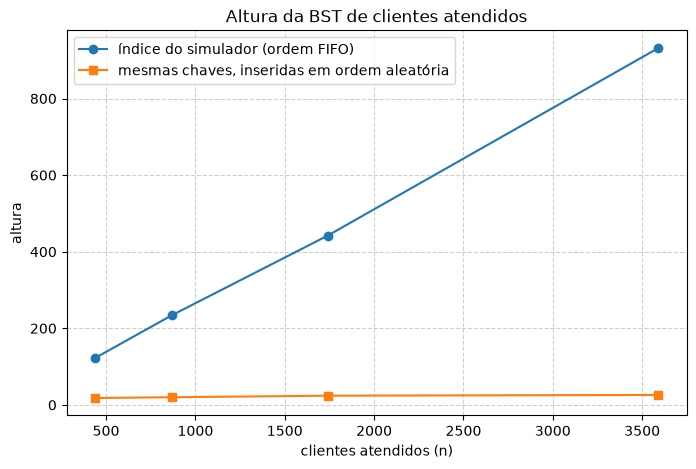

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(altura["atendidos (n)"], altura["altura_indice_FIFO"], marker="o", label="índice do simulador (ordem FIFO)")
plt.plot(altura["atendidos (n)"], altura["altura_mesmas_chaves_embaralhadas"], marker="s",
         label="mesmas chaves, inseridas em ordem aleatória")
plt.title("Altura da BST de clientes atendidos")
plt.xlabel("clientes atendidos (n)")
plt.ylabel("altura")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

A altura do índice cresce junto com n (`altura / n` perto de 1/4, uma cadeia de chaves por fila), enquanto com as chaves embaralhadas ela fica perto de 2·log₂ n. Então aqui a busca é O(n) na prática, por causa da própria regra FIFO. A solução seria uma árvore balanceada, como a AVL, ou uma tabela hash se só for preciso buscar pelo identificador.

## 7. Casos de borda

In [11]:
# string vazia: nada acontece, nada quebra
vazio = Simulador().processar("")
assert vazio.log == [] and vazio.atendidos == 0 and vazio.indice.in_order() == []

# só snapshots
so_snap = Simulador().processar("*#1 ")
assert len(so_snap.snapshots) == 4 and so_snap.atendidos == 0

# só saídas: todas viram underflow, e a simulação segue
so_saida = Simulador().processar("ABCD")
assert all(e["tipo"] == "ERRO" for e in so_saida.log) and len(so_saida.log) == 4

# fila de capacidade 1: o segundo cliente é recusado, o terceiro entra depois que o primeiro sai
cap1 = Simulador(capacidade=1).processar("aaAa")
assert [e["tipo"] for e in cap1.log] == ["chegada", "ERRO", "saída", "chegada"]
assert cap1.indice.search("A1")[0]["cliente"] == "A1"
assert cap1.indice.search("A2")[0] is None        # o A2 foi recusado, nunca foi atendido

# a busca aceita minúscula e recusa identificador malformado
assert cap1.indice.search("a1")[0]["cliente"] == "A1"
for invalido in ["", "B", "17", "B1x", None]:
    try:
        cap1.indice.search(invalido)
        raise AssertionError(f"deveria recusar {invalido!r}")
    except ValueError:
        pass

print("todos os casos de borda passaram")

todos os casos de borda passaram
